In [67]:
import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline

words = open("../src/data/names.txt", 'r').read().splitlines()

In [68]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}; stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [69]:
block_size = 3  # context length of how many input we are taking to predict the next output
X, Y = [], []

# create sliding window of block size over each input
for w in words:
    # print(w)
    context = [0] * block_size
    for c in w + '.':
        ix = stoi[c]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[ctx] for ctx in context), "--->" ,c)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [20]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [81]:
# build embedding lookup table C - cramp them into a 2-dimensional vector
C = torch.randn((27, 2))

# Vaild ways to index from the embedding
# C[5]
# C[[5,6,7]]
# C[torch.tensor([5,6,7])]
# C[torch.tensor([5,6,6,6,6])] - retrieve a row multiple times

# we could first index from X, then index from Y using the result, i.e.
# idx = X[1,2], then
# C[idx]
# or just do the following!
# C[X][1,2]
# so our embedding is simply
emb = C[X]

In [73]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [201]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
#                     the plus here ^
# performs "boardcasting" which is element-wise addition, not the list as a whole

# Broadcasting
# [1, 2, 3] + [4, 5, 6] == [5, 7, 9]
# Default
# [1, 2, 3] + [4, 5, 6] == [1, 2, 3, 4, 5, 6] 

In [276]:
# Final layer - same as before!
W2 = torch.randn(100, 27)
b2 = torch.randn(27)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(32)].log().mean()

In [221]:
# ------------------------
# Now everything together
# ------------------------

In [21]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [22]:
sum(p.nelement() for p in parameters)

3481

In [310]:
# how do I know what learning rate is best?
# we could try arbitrary numbers until it looks OK-ish
# or we could systematically try a range of rates that made sense
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
# at the end we have a list of learning rates that increases exponentially

In [23]:
lri = []
lossi = []

for i in range(10000):
    # mini-batching
    ix = torch.randint(0, X.shape[0], (32,))
    
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    
    # you know, I wish we don't have to repeat this everytime
    # what? this is such a common operation that pytorch have built in a function to do exactly that?
    # also you're telling me pytorch handles extreme numbers well too?
    # sign me the fuck up
    loss = F.cross_entropy(logits, Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # keep tracking of lrs
    # lri.append(lre[i])
    # lossi.append(loss.item())

print(loss.item())

2.5469515323638916


In [24]:
def forward_pass(X, Y):
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y).item()

forward_pass(X, Y)

2.5064730644226074

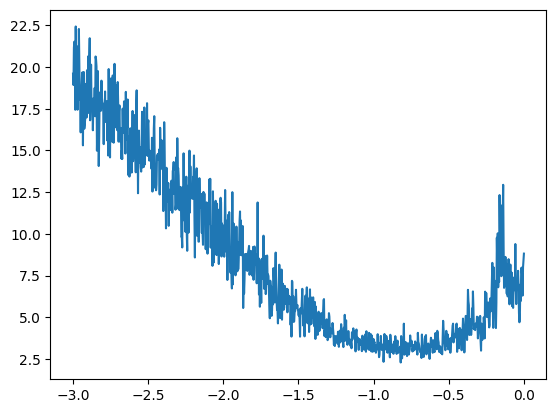

In [228]:
plt.plot(lri, lossi)

In [271]:
# ---------------------
# Combating overfitting
# ---------------------

In [25]:
# 3 splits: training (80%), dev/validation (10%), test (10%)

def build_dataset(words):
    block_size = 3
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for c in w + '.':
            ix = stoi[c]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [26]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[:n2])

In [27]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [28]:
for i in range(10000):
    # mini-batching
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    for p in parameters:
        p.data += -0.01 * p.grad

In [29]:
# training set
forward_pass(Xtr, Ytr)

2.5746371746063232

In [30]:
# dev set
forward_pass(Xdev, Ydev)

2.569575309753418

In [ ]:
# -----------
# Experiments
# -----------

In [84]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[:n2])

In [85]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
# 3 block size (input) * 10 dimension (which we increased above)
# AND increasing neurons in hidden layer - tuning hyperparameter
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [86]:
stepi = []
lossi = []

In [87]:
for i in range(100_000):
    # mini-batching
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 50000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

1.9131360054016113


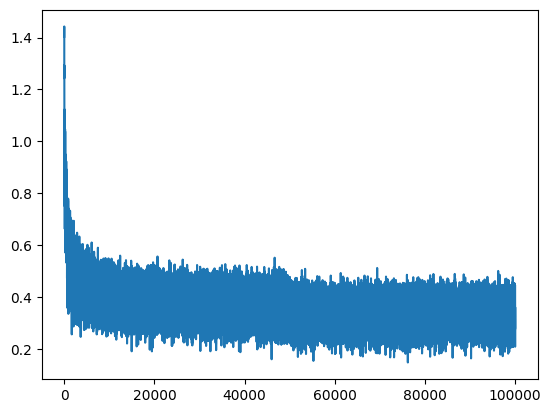

In [88]:
plt.plot(stepi, lossi)

In [89]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev).item()
loss

2.1982736587524414

In [95]:
# sampling from the model
g = torch.Generator().manual_seed(2147483647+10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]  # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = torch.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmah.
ameriq.
khirmin.
reviyah.
cassie.
rahnen.
delyah.
jarqui.
nellara.
chaiir.
kalej.
phann.
joce.
quint.
srovera.
jadiquo.
jero.
dearynix.
kaen.
ivraylen.
